# Ex0 — Intro to GNSS Navigation

**Goal:** Process a RINEX 4.0 observation file to compute a 1 Hz offline path (lat, lon, alt) and export it as a CSV and KML file.

---

## Table of Contents
1. [Installation](#1-installation)
2. [Imports](#2-imports)
3. [Load Data from GitHub](#3-load-data-from-github)
4. [Constants & Preprocessing](#4-constants--preprocessing)
5. [Satellite Position Functions](#5-satellite-position-functions)
6. [Pseudorange Correction](#6-pseudorange-correction)
7. [Positioning & Coordinate Utilities](#7-positioning--coordinate-utilities)
8. [Trajectory Computation](#8-trajectory-computation)
9. [Export Results](#9-export-results)

---

## 1. Installation
Install required libraries if not already available.

In [1]:
!pip install georinex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.4 MB/s eta 0:00:00


In [2]:
!pip install gnss-lib-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
  Created wheel for georinex: filename=georinex-1.16.1-py3-none-any.whl size=43931 sha256=40640d9630dedec398668a0793c150878430fdecaf594fd5583ef02f69404c8f
  Stored in directory: /root/.cache/pip/wheels/37/9c/42/7f443a89f92e0ce2fbb63168529461d9997ec771ec639aa89a
Successfully built georinex
  Attempting uninstall: 

In [3]:
!pip install simplekml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=d7333ae73ff587c1cb724fc76ad8abaae1b71b6150157f13ec3349ae5c0fae13
  Stored in directory: /root/.cache/pip/wheels/83/ee/f2/65cecfd948f1429ead035fd6d56bc6bd6574a636ddc4d65cbd
Successfully built simplekml


## 2. Imports
Import all required libraries for GNSS processing, math, and data handling.

In [4]:
import georinex as gr
import numpy as np
import pandas as pd
import os
import xarray as xr

In [5]:
import gnss_lib_py as glp
from gnss_lib_py.utils.ephemeris_downloader import load_ephemeris
from datetime import datetime, timezone

## 3. Load Data from GitHub
Download the RINEX navigation (`.rnx`) and observation (`.26o`) files directly from the GitHub repository, then load them using `georinex`.

In [6]:
import urllib.request
import os

# ── GitHub raw base URL ──────────────────────────────────────────────────────
GITHUB_BASE = 'https://raw.githubusercontent.com/amitd55/Ex0-Intro_to_GNSS_navigation/main/rawgnss'

# Download navigation (broadcast ephemeris) file
nav_filename = 'BRDC00IGS_R_20260800000_01D_MN.rnx'
urllib.request.urlretrieve(f'{GITHUB_BASE}/{nav_filename}', nav_filename)
print(f'Downloaded: {nav_filename}')

# Download observation file
obs_filename = 'gnss_log_2026_03_21_17_17_57.26o'
urllib.request.urlretrieve(f'{GITHUB_BASE}/{obs_filename}', obs_filename)
print(f'Downloaded: {obs_filename}')


Mounted at /content/drive


In [7]:
import georinex as gr

# Load GPS-only navigation data from downloaded file
nav_file_path = nav_filename

try:
    nav_data = gr.load(nav_file_path, use='G')
    print('Success! GPS nav data loaded.')
except Exception as e:
    print(f'Error loading nav file: {e}')


/usr/local/lib/python3.12/dist-packages/georinex/nav3.py:135: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  nav = xarray.merge((nav, xarray.Dataset(dsf, coords={"time": tu, "sv": [svv]})))
/usr/local/lib/python3.12/dist-packages/georinex/nav3.py:135: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'sv' ('sv',) The recommendation is to set join explicitly for this case.
  nav = xarray.merge((nav, xarray.Dataset(dsf, coords={"time": tu, "s

Success! GPS and Galileo maps loaded.


/usr/local/lib/python3.12/dist-packages/georinex/nav3.py:135: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  nav = xarray.merge((nav, xarray.Dataset(dsf, coords={"time": tu, "sv": [svv]})))
/usr/local/lib/python3.12/dist-packages/georinex/nav3.py:135: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  nav = xarray.merge((nav, xarray.Dataset

In [ ]:
# Observation file already downloaded above
# To switch files, change obs_filename in the download cell and re-run
obs_file_path = obs_filename


In [ ]:
obs = gr.load(obs_file_path)
print(f'Observation file loaded: {obs_file_path}')


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/georinex/obs3.py:246: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  data = xarray.merge((data, epoch_data))
/usr/local/lib/python3.12/dist-packages/georinex/obs3.py:246: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  data = xarray.merge((data, ep

## 4. Constants & Preprocessing
Define physical constants and parse the observation + navigation data into aligned DataFrames indexed by GPS time-of-week (SOW).

In [ ]:
mu = 3.986004418e14        # Earth's gravitational constant (m^3/s^2)
omega_e = 7.2921151467e-5  # Earth's rotation rate (rad/s)
c = 2.99792458e8           # Speed of light (m/s)
F = -4.442807633e-10


In [ ]:
gps_epoch = pd.Timestamp('1980-01-06', tz='UTC')

selected_svs = [sv for sv in obs.sv.values if sv.startswith('G') ]

pi_df = obs.sel(sv=selected_svs).to_dataframe().reset_index()
pi_df = pi_df.dropna(subset=['C1C'])

pi_df['time'] = pd.to_datetime(pi_df['time']).dt.tz_localize('UTC')
pi_df['time_seconds'] = (pi_df['time'] - gps_epoch).dt.total_seconds() % 604800

nav_df = nav_data.to_dataframe().dropna(how='all').reset_index()

nav_df['time'] = pd.to_datetime(nav_df['time']).dt.tz_localize('UTC')
nav_df['time_seconds'] = (nav_df['time'] - gps_epoch).dt.total_seconds() % 604800

## 5. Satellite Position Functions
Core GNSS functions:
- **`find_closest_nav`** — finds the nearest ephemeris record for a satellite at a given time
- **`compute_sat_pos`** — computes ECEF satellite position (X, Y, Z) and clock bias from Keplerian orbital elements
- **`process_row`** — applies the above two functions row-wise across the observation DataFrame

In [ ]:
def find_closest_nav(sv, obs_time_sow, nav_df):
    sv_nav = nav_df[nav_df['sv'] == sv]
    if sv_nav.empty:
        return None

    diffs = (sv_nav['time_seconds'] - obs_time_sow).abs()
    idx = diffs.idxmin()

    if diffs[idx] > 7200:
        return None

    return sv_nav.loc[idx]

In [ ]:
def compute_sat_pos(nav_row, obs_time_sow):

    A = nav_row['sqrtA']**2
    e = nav_row['Eccentricity']
    toe = nav_row['Toe']

    tk = obs_time_sow - toe
    if tk > 302400:  tk -= 604800
    if tk < -302400: tk += 604800


    n = np.sqrt(mu / A**3) + nav_row['DeltaN']
    Mk = nav_row['M0'] + n * tk


    Ek = Mk
    for _ in range(10):
        Ek = Mk + e * np.sin(Ek)


    d_rel = F * e * nav_row['sqrtA'] * np.sin(Ek)

    dt_ref = nav_row['time_seconds']
    dts = (nav_row['SVclockBias'] +
           nav_row['SVclockDrift'] * (obs_time_sow - dt_ref) +
           d_rel - nav_row['TGD'])


    vk = np.arctan2(np.sqrt(1 - e**2) * np.sin(Ek), np.cos(Ek) - e)
    phi_k = vk + nav_row['omega']

    uk = phi_k + nav_row['Cus']*np.sin(2*phi_k) + nav_row['Cuc']*np.cos(2*phi_k)
    rk = A*(1 - e*np.cos(Ek)) + nav_row['Crs']*np.sin(2*phi_k) + nav_row['Crc']*np.cos(2*phi_k)
    ik = nav_row['Io'] + nav_row['IDOT']*tk + nav_row['Cis']*np.sin(2*phi_k) + nav_row['Cic']*np.cos(2*phi_k)

    Ok = nav_row['Omega0'] + (nav_row['OmegaDot'] - omega_e)*tk - omega_e*toe

    Xk = rk * (np.cos(uk)*np.cos(Ok) - np.sin(uk)*np.cos(ik)*np.sin(Ok))
    Yk = rk * (np.cos(uk)*np.sin(Ok) + np.sin(uk)*np.cos(ik)*np.cos(Ok))
    Zk = rk * (np.sin(uk)*np.sin(ik))

    return Xk, Yk, Zk, dts

In [ ]:
def process_row(row, nav_df):
    nav_row = find_closest_nav(row['sv'], row['time_seconds'], nav_df)

    if nav_row is not None:
        Xk, Yk, Zk, dts = compute_sat_pos(nav_row, row['time_seconds'])
        return pd.Series([Xk, Yk, Zk, dts], index=['Xk', 'Yk', 'Zk', 'dts'])
    else:
        return pd.Series([None, None, None, None], index=['Xk', 'Yk', 'Zk', 'dts'])

Apply satellite position computation across all observation epochs.

In [ ]:
sat_results = pi_df.apply(process_row, axis=1, args=(nav_df,))
final_df = pd.concat([pi_df, sat_results], axis=1)

## 6. Pseudorange Correction
Correct raw pseudoranges (`C1C`) by applying the satellite clock bias (`dts`), producing clean pseudoranges (`CleanPi`).

In [ ]:
def calculate_clean_pi(row):
    if pd.isna(row['Xk']):
        return None

    return row['C1C'] + (c * row['dts'])


In [ ]:
final_df['CleanPi'] = final_df.apply(calculate_clean_pi, axis=1)
final_df = final_df.dropna(subset=['CleanPi'])

## 7. Positioning & Coordinate Utilities
Helper functions for the least-squares solver:
- **`get_elevation_angle`** — filters low-elevation satellites (below mask angle)
- **`least_squares_position`** — iterative weighted least-squares to solve for receiver ECEF position and clock offset
- **`compute_rms`** — computes RMS of pseudorange residuals per epoch
- **`ecef_to_geodetic`** — converts ECEF (X, Y, Z) to geodetic (lat, lon, alt) using pyproj

In [ ]:
def get_elevation_angle(xs, ys, zs, xr, yr, zr):
    lat, lon, _ = ecef_to_geodetic(xr, yr, zr)
    lat_rad, lon_rad = np.radians(lat), np.radians(lon)

    dx, dy, dz = xs - xr, ys - yr, zs - zr
    distance = np.sqrt(dx**2 + dy**2 + dz**2)

    up_x = np.cos(lat_rad) * np.cos(lon_rad)
    up_y = np.cos(lat_rad) * np.sin(lon_rad)
    up_z = np.sin(lat_rad)

    sin_el = (up_x * dx + up_y * dy + up_z * dz) / distance
    return np.degrees(np.arcsin(sin_el))


In [ ]:
def least_squares_position(epoch, guess, elev_mask=5.0, max_iter=20, tol=0.1):


    if np.all(guess[:3] == 0):
        sat_mean = epoch[['Xk', 'Yk', 'Zk']].mean().values
        norm = np.linalg.norm(sat_mean)
        guess[:3] = (sat_mean / norm) * 6371000.0
        first_pr = epoch['CleanPi'].iloc[0]
        dist_to_first = np.linalg.norm(guess[:3] - epoch[['Xk', 'Yk', 'Zk']].iloc[0])
        guess[3] = first_pr - dist_to_first

    for iteration in range(max_iter):
        A, b, used_idx = [], [], []

        for idx, row in epoch.iterrows():
            Xs, Ys, Zs = row['Xk'], row['Yk'], row['Zk']
            pr = row['CleanPi']

            el = get_elevation_angle(Xs, Ys, Zs, guess[0], guess[1], guess[2])
            if el < elev_mask: continue


            dist_coarse = np.sqrt((guess[0]-Xs)**2 + (guess[1]-Ys)**2 + (guess[2]-Zs)**2)
            theta = omega_e * (dist_coarse / c)

            Xs_r = Xs * np.cos(theta) + Ys * np.sin(theta)
            Ys_r = -Xs * np.sin(theta) + Ys * np.cos(theta)

            dx = guess[0] - Xs_r
            dy = guess[1] - Ys_r
            dz = guess[2] - Zs
            rho = np.sqrt(dx**2 + dy**2 + dz**2)

            A.append([dx/rho, dy/rho, dz/rho, 1.0])
            b.append(pr - rho - guess[3])
            used_idx.append(idx)

        if len(A) < 4: break

        A, b = np.array(A), np.array(b)
        delta, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        guess += delta

        if np.linalg.norm(delta[:3]) < tol: break

    return guess, used_idx

In [ ]:
def compute_rms(epoch, ecef_pos, used_idx):
    residuals = []

    for idx in used_idx:
        row = epoch.loc[idx]

        dx = row['Xk'] - ecef_pos[0]
        dy = row['Yk'] - ecef_pos[1]
        dz = row['Zk'] - ecef_pos[2]
        rho = np.sqrt(dx**2 + dy**2 + dz**2)

        res = row['CleanPi'] - (rho + ecef_pos[3])
        residuals.append(res)

    if len(residuals) == 0:
        return None, 0

    residuals = np.array(residuals)

    rms = np.sqrt(np.mean(residuals**2))

    return rms, len(residuals)

In [ ]:
from pyproj import Transformer
from pyproj import CRS
crs = CRS.from_epsg(4326)

def ecef_to_geodetic(x,y,z):
  transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)
  lon, lat, alt = transformer.transform(x, y, z)

  return lat, lon, alt


## 8. Trajectory Computation
Main processing loop — iterates over each 1 Hz epoch, applies satellite position refinement using signal travel time, runs two-pass least-squares positioning, and collects valid fixes.

In [ ]:
trajectory_results = []
current_guess = np.array([0.0, 0.0, 0.0, 0.0])

for timestamp_sow, epoch in final_df.groupby('time_seconds'):
    clean_epoch = epoch.dropna(subset=['Xk', 'Yk', 'Zk', 'CleanPi']).copy()
    if len(clean_epoch) < 4: continue

    res_p1, used_idx_p1 = least_squares_position(clean_epoch, current_guess.copy())
    if res_p1 is None: continue

    dt_seconds = res_p1[3] / c

    for idx, row in clean_epoch.iterrows():
        tau = row['C1C'] / c
        tx_time = timestamp_sow - dt_seconds - tau

        nav_row = find_closest_nav(row['sv'], tx_time, nav_df)
        if nav_row is not None:
            xk, yk, zk, dts = compute_sat_pos(nav_row, tx_time)
            clean_epoch.at[idx, 'Xk'] = xk
            clean_epoch.at[idx, 'Yk'] = yk
            clean_epoch.at[idx, 'Zk'] = zk
            clean_epoch.at[idx, 'CleanPi'] = row['C1C'] + (c * dts)

    final_res, used_idx_p2 = least_squares_position(clean_epoch, res_p1)
    if final_res is None: continue

    current_guess = final_res

    rms_value, n_clean = compute_rms(clean_epoch, final_res, used_idx_p2)
    lat, lon, alt = ecef_to_geodetic(final_res[0], final_res[1], final_res[2])

    if -100 < alt < 3000:
        trajectory_results.append({'time_sow': timestamp_sow, 'lat': lat, 'lon': lon, 'alt': alt, 'rms': rms_value, 'sat_count': n_clean})

final_path_df = pd.DataFrame(trajectory_results)

Preview the resulting trajectory DataFrame.

In [ ]:
final_path_df

,time_sow,lat,lon,alt,rms,sat_count
0,573495.41888,32.168747,34.813630,51.269623,0.115747,5
1,573496.41888,32.168817,34.813591,104.705873,2.756122,5
2,573497.41888,32.168729,34.813388,78.350031,2.828421,5
3,573498.41888,32.169359,34.814150,94.677147,0.000286,4
4,573499.41888,32.168713,34.813401,60.690234,10.158088,6
...,...,...,...,...,...,...
266,573761.41888,32.168608,34.813452,92.646713,4.545035,6
267,573762.41888,32.168605,34.813609,91.996657,0.000281,4
268,573763.41888,32.168400,34.813437,36.889349,3.580715,5
269,573764.41888,32.168548,34.813441,82.560670,0.000259,4


## 9. Export Results
Save the computed trajectory as a **CSV** file and a **KML** file for visualization in Google Earth.
Output files can be downloaded from the Colab file browser (📁 icon on the left sidebar).

In [ ]:
# Save trajectory to CSV (download from Colab file browser on the left)
output_csv = 'final_path_df.csv'
final_path_df.to_csv(output_csv, index=False)
print(f'Saved: {output_csv}')


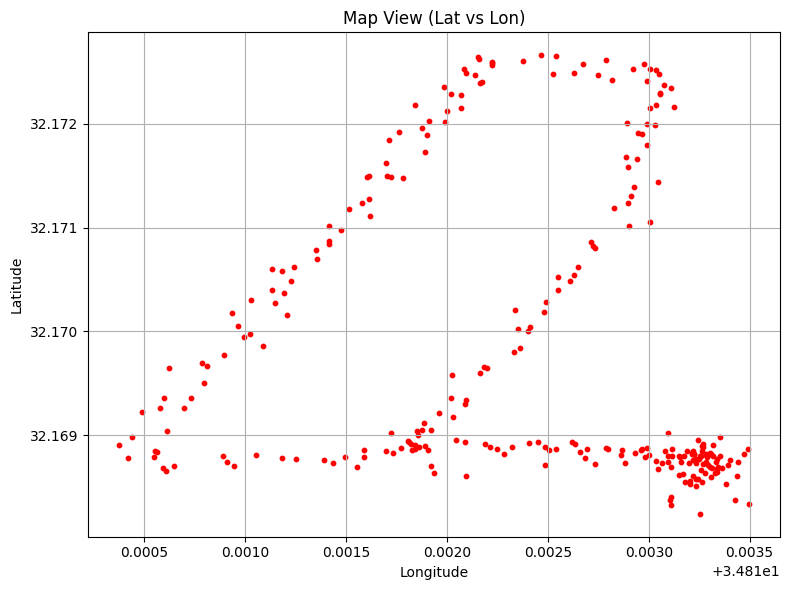

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6)) # Create only one subplot

ax1.scatter(final_path_df['lon'], final_path_df['lat'], c='red', s=10)
ax1.set_title("Map View (Lat vs Lon)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import simplekml

# Save KML locally (download from Colab file browser on the left)
def export_to_kml(df, filename="my_trajectory.kml"):

    kml = simplekml.Kml()

    point_folder = kml.newfolder(name="Trajectory Points")

    for idx, row in df.iterrows():
        pnt = point_folder.newpoint(name="")
        pnt.coords = [(row['lon'], row['lat'], row['alt'])]

        pnt.style.iconstyle.icon.href = 'http://maps.google.com/mapfiles/kml/pushpin/red-pushpin.png'
        pnt.style.iconstyle.scale = 0.8

        pnt.description = ""

        pnt.altitudemode = simplekml.AltitudeMode.clamptoground
        pnt.extrude = 0

    line_folder = kml.newfolder(name="Trajectory Line")
    ls = line_folder.newlinestring(name="Full Trajectory")
    ls.coords = [(row['lon'], row['lat'], row['alt']) for index, row in df.iterrows()]

    ls.altitudemode = simplekml.AltitudeMode.clamptoground
    ls.extrude = 0
    ls.tessellate = 1

    ls.style.linestyle.color = simplekml.Color.red
    ls.style.linestyle.width = 3

    kml.save(filename)
    print(f"Success! KML file saved as: {filename}")

export_to_kml(final_path_df)

Success! KML file saved as: /content/drive/MyDrive/EX0/my_trajectory.kml
